# Lesson 01 — OLS Foundations & statsmodels

<h2 dir="rtl">פרק 1 — טעינת ספריות</h2>

In [1]:
# If statsmodels isn't installed, uncomment the next line:
# !pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle as pkl

<h2 dir="rtl">פרק 2 — נטען את הדאטה</h2>

In [2]:
y_vals_tirgul_1 = pkl.load(open('../pkl/y_vals_tirgul_1.pkl', 'rb'))

num_points = 45
x_vals = np.linspace(2, 12, num_points)
x_vals1 = sm.add_constant(x_vals)

In [3]:
df_data = pd.DataFrame(
    np.append(x_vals1.reshape(x_vals1.shape[0], 2),
              y_vals_tirgul_1.reshape(x_vals.shape[0], 1), axis=1),
    columns=['intercept', 'experience', 'severity'],
)
df_data.head()

,intercept,experience,severity
0,1.0,2.000000,102.254323
1,1.0,2.227273,82.437164
2,1.0,2.454545,104.149337
3,1.0,2.681818,91.398245
4,1.0,2.909091,90.637359


<h2 dir="rtl">פרק 3 — Statsmodels OLS</h2>

In [4]:
model = sm.OLS(df_data['severity'], df_data[['intercept', 'experience']])
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               severity   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     109.2
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.22e-13
Time:                        20:10:20   Log-Likelihood:                -141.75
No. Observations:                  45   AIC:                             287.5
Df Residuals:                      43   BIC:                             291.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     99.9495      2.217     45.093      0.0

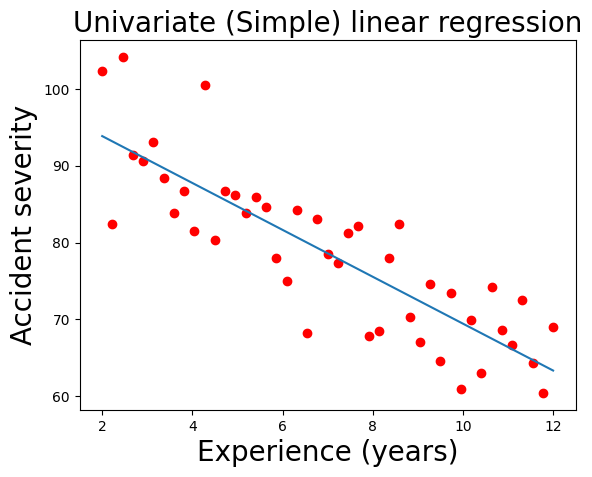

In [5]:
plt.figure()
plt.scatter(x_vals, y_vals_tirgul_1, color='r')
plt.plot(x_vals, results.predict(x_vals1))
plt.xlabel('Experience (years)', fontsize=20)
plt.ylabel('Accident severity', fontsize=20)
plt.title('Univariate (Simple) linear regression', fontsize=20)
plt.show()

<h2 dir="rtl">פרק 4 — חישוב ידני של $\hat{b}$</h2>

In [6]:
X = x_vals
Y = y_vals_tirgul_1

mean_X = np.mean(X)
mean_Y = np.mean(Y)

numerator = np.sum((X - mean_X) * (Y - mean_Y))
denominator = np.sum((X - mean_X) ** 2)
beta1 = numerator / denominator
beta0 = mean_Y - beta1 * mean_X

print('Slope (beta1):', beta1)
print('Intercept (beta0):', beta0)

Slope (beta1): -3.049510640272108
Intercept (beta0): 99.94951155804033


<h2 dir="rtl">פרק 5 — $R^2$ ויזואלית (SST vs SSR)</h2>

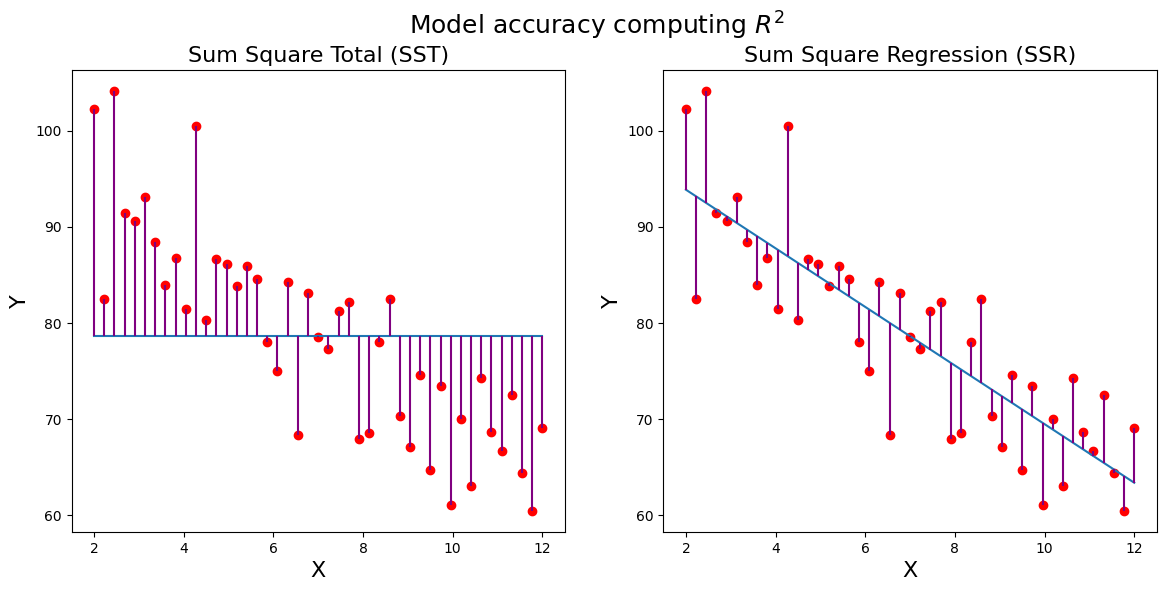

In [7]:
fontsize = 16
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model accuracy computing $R^2$', fontsize=fontsize + 2)

# Left: SST (deviations from the mean)
ax1.scatter(x_vals, y_vals_tirgul_1, color='r')
ax1.plot(x_vals, np.ones(y_vals_tirgul_1.shape[0]) * y_vals_tirgul_1.mean())
ax1.vlines(x=x_vals,
           ymin=y_vals_tirgul_1,
           ymax=np.ones(y_vals_tirgul_1.shape[0]) * y_vals_tirgul_1.mean(),
           colors='purple')
ax1.set_xlabel('X', fontsize=fontsize)
ax1.set_ylabel('Y', fontsize=fontsize)
ax1.set_title('Sum Square Total (SST)', fontsize=fontsize)

# Right: SSR (residuals from regression line)
ax2.scatter(x_vals, y_vals_tirgul_1, color='r')
ax2.plot(x_vals, results.predict(x_vals1))
ax2.vlines(x=x_vals,
           ymin=y_vals_tirgul_1,
           ymax=results.predict(x_vals1),
           colors='purple')
ax2.set_xlabel('X', fontsize=fontsize)
ax2.set_ylabel('Y', fontsize=fontsize)
ax2.set_title('Sum Square Regression (SSR)', fontsize=fontsize)

plt.show()

<h2 dir="rtl">פרק 6 — חיזוי</h2>

In [8]:
# 10 years of experience — inside training range (interpolation)
Severity = 99.9495 - 3.0495 * 10
Severity, results.predict(np.array([1, 10]))

(69.4545, array([69.45440516]))

In [9]:
# 30 years of experience — outside training range (extrapolation)
Severity = 99.9495 - 3.0495 * 30
Severity, results.predict(np.array([1, 30]))

(8.464500000000001, array([8.46419235]))

<h2 dir="rtl">פרק 8 — בדיקת 3 הנחות המודל</h2>

### 1. Linearity

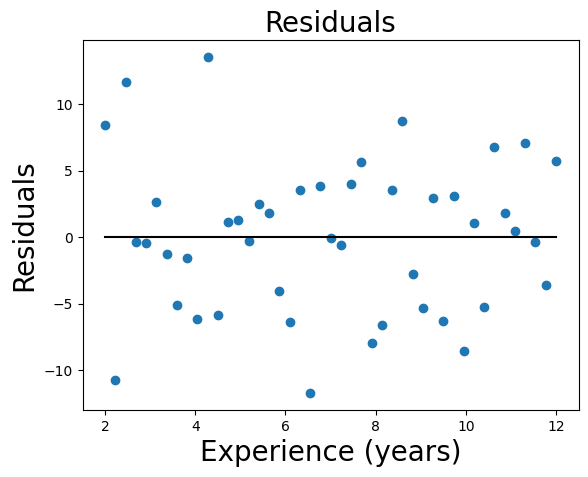

In [10]:
plt.figure()
plt.scatter(x_vals, results.resid)
plt.plot(x_vals, np.zeros(x_vals.shape[0]), color='black')
plt.xlabel('Experience (years)', fontsize=20)
plt.ylabel('Residuals', fontsize=20)
plt.title('Residuals', fontsize=20)
plt.show()

### 2. Homoscedasticity

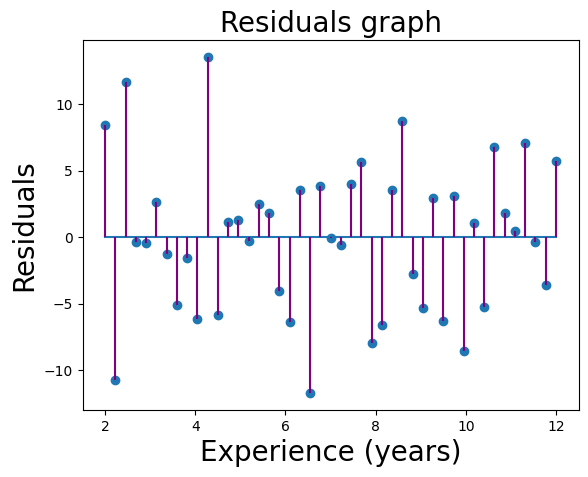

In [11]:
plt.figure()
plt.scatter(x_vals, results.resid)
plt.plot(x_vals, np.zeros(x_vals.shape[0]))
plt.vlines(x=x_vals,
           ymin=results.resid,
           ymax=np.zeros(x_vals.shape[0]),
           colors='purple')
plt.title('Residuals graph', fontsize=20)
plt.xlabel('Experience (years)', fontsize=20)
plt.ylabel('Residuals', fontsize=20)
plt.show()

### 3. Normality

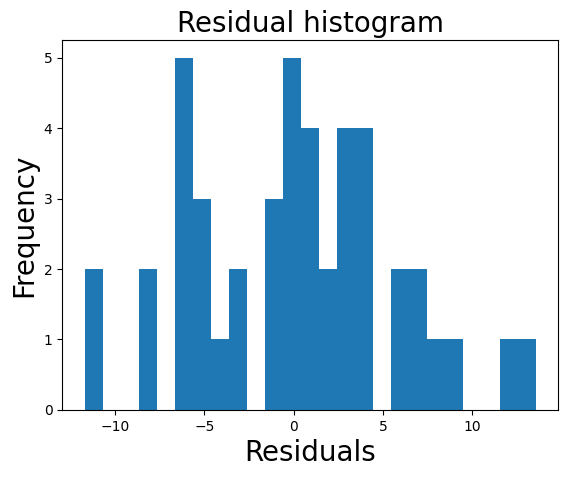

In [12]:
plt.figure()
plt.hist(results.resid, bins=25)
plt.xlabel('Residuals', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.title('Residual histogram', fontsize=20)
plt.show()